In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DONE

In [3]:

# ==========================================
# 1. خواندن داده
# ==========================================

data = pd.read_csv("E:/pro/uni_project/adjusted_dataset_mlALL.csv")
df = data.copy()

df = df.dropna()

In [4]:
# ==========================================
# FINAL FEATURE ENGINEERING
# ==========================================

import numpy as np
import pandas as pd

# ------------------------------------------
# 1. آماده‌سازی داده
# ------------------------------------------

df = df.copy().sort_index()

df["CLOSE"] = df["adj_close"]
df["HIGH_LOW"] = df["adj_high"] - df["adj_low"]
df["OPEN_CLOSE"] = df["adj_close"] - df["adj_open"]

df["OPEN_CLOSE_PCT"] = (
    (df["adj_close"] - df["adj_open"]) / df["adj_open"]
) * 100

df["CLOSE_CHANGE_PCT"] = df["adj_close"].pct_change() * 100
df["VOLUME"] = df["VOL"]

df["MA_5"] = df["CLOSE"].rolling(5).mean()
df["MA_10"] = df["CLOSE"].rolling(10).mean()
df["VOL_MA_5"] = df["VOLUME"].rolling(5).mean()


# ------------------------------------------
# 2. Lag Features
# ------------------------------------------

for lag in range(1, 21):
    df[f"CLOSE_LAG_{lag}"] = df["CLOSE"].shift(lag)


# ------------------------------------------
# 3. Returns
# ------------------------------------------

for period in [1, 3, 5, 10, 20]:
    df[f"RETURN_{period}"] = df["CLOSE"].pct_change(period)


# ------------------------------------------
# 4. Moving Averages
# ------------------------------------------

df["MA_20"] = df["CLOSE"].rolling(20).mean()
df["MA_60"] = df["CLOSE"].rolling(60).mean()

for ma in [5, 10, 20, 60]:
    df[f"CLOSE_MA{ma}_DIFF_PCT"] = (
        (df["CLOSE"] - df[f"MA_{ma}"]) / df[f"MA_{ma}"]
    ) * 100


# ------------------------------------------
# 5. Volatility
# ------------------------------------------

for period in [5, 10, 20, 60]:
    df[f"STD_{period}"] = df["CLOSE"].rolling(period).std()


# ------------------------------------------
# 6. EWMA
# ------------------------------------------

df["EWMA_12"] = df["CLOSE"].ewm(
    span=12, adjust=False
).mean()

df["EWMA_26"] = df["CLOSE"].ewm(
    span=26, adjust=False
).mean()


# ------------------------------------------
# 7. RSI
# ------------------------------------------

delta = df["CLOSE"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))
df["RSI_CHANGE"] = df["RSI_14"].diff()


# ------------------------------------------
# 8. MACD
# ------------------------------------------

ema_12 = df["CLOSE"].ewm(
    span=12, adjust=False
).mean()

ema_26 = df["CLOSE"].ewm(
    span=26, adjust=False
).mean()

df["MACD"] = ema_12 - ema_26

df["MACD_SIGNAL"] = df["MACD"].ewm(
    span=9, adjust=False
).mean()

df["MACD_HIST"] = (
    df["MACD"] - df["MACD_SIGNAL"]
)


# ------------------------------------------
# 9. Momentum
# ------------------------------------------

df["ROC_5"] = df["CLOSE"].pct_change(5)
df["ROC_10"] = df["CLOSE"].pct_change(10)


# ------------------------------------------
# 10. Bollinger Band Width
# ------------------------------------------

rolling_mean_20 = df["CLOSE"].rolling(20).mean()
rolling_std_20 = df["CLOSE"].rolling(20).std()

upper_band = rolling_mean_20 + 2 * rolling_std_20
lower_band = rolling_mean_20 - 2 * rolling_std_20

df["BB_WIDTH"] = (
    (upper_band - lower_band) / rolling_mean_20
)


# ------------------------------------------
# 11. Realized Volatility
# ------------------------------------------

returns = df["CLOSE"].pct_change()

df["REALIZED_VOLATILITY"] = (
    returns.rolling(20).std() * np.sqrt(20)
)


# ------------------------------------------
# 12. Volume Features
# ------------------------------------------

df["VOL_MA_20"] = df["VOLUME"].rolling(20).mean()

df["VOLUME_RATIO"] = (
    df["VOLUME"] / df["VOL_MA_20"]
)

df["VOLUME_CHANGE"] = df["VOLUME"].pct_change()

df["VOL_MA_RATIO_5_20"] = (
    df["VOL_MA_5"] / df["VOL_MA_20"]
)


# ------------------------------------------
# 13. Target
# ------------------------------------------

df["TARGET"] = df["CLOSE"].shift(-1)


# ==========================================
# 14. Final Features
# ==========================================

features_engineered = [
    # Price / Daily Movement
    "HIGH_LOW",
    "OPEN_CLOSE",
    "OPEN_CLOSE_PCT",
    "CLOSE_CHANGE_PCT",

    # Volume
    "VOLUME",
    "VOL_MA_5",

    # Lag
    *[f"CLOSE_LAG_{i}" for i in range(1, 21)],

    # Returns
    "RETURN_1",
    "RETURN_3",
    "RETURN_5",
    "RETURN_10",
    "RETURN_20",

    # Moving Average Distance
    "CLOSE_MA5_DIFF_PCT",
    "CLOSE_MA10_DIFF_PCT",
    "CLOSE_MA20_DIFF_PCT",
    "CLOSE_MA60_DIFF_PCT",

    # Volatility
    "STD_5",
    "STD_10",
    "STD_20",
    "STD_60",

    # EWMA
    "EWMA_12",
    "EWMA_26",

    # RSI
    "RSI_14",
    "RSI_CHANGE",

    # MACD
    "MACD",
    "MACD_SIGNAL",
    "MACD_HIST",

    # Momentum
    "ROC_5",
    "ROC_10",
    "BB_WIDTH",
    "REALIZED_VOLATILITY",

    # Volume Indicators
    "VOL_MA_20",
    "VOLUME_RATIO",
    "VOLUME_CHANGE",
    "VOL_MA_RATIO_5_20"
]


# ==========================================
# 15. ساخت دیتاست نهایی
# ==========================================

model_df = df[
    features_engineered + ["TARGET"]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna().copy()


# ==========================================
# 16. Train / Test Split
# ==========================================

split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[features_engineered]
y_train = train_df["TARGET"]

X_test = test_df[features_engineered]
y_test = test_df["TARGET"]


# ==========================================
# نمایش اطلاعات
# ==========================================

print("=" * 50)
print("FINAL DATASET")
print("=" * 50)

print("Number of rows:", len(model_df))
print("Number of features:", len(features_engineered))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nFeatures:")
for i, feature in enumerate(features_engineered, 1):
    print(f"{i:2d}. {feature}")

print("\nTARGET = CLOSE of next day")

FINAL DATASET
Number of rows: 4137
Number of features: 54
X_train: (3309, 54)
X_test : (828, 54)

Features:
 1. HIGH_LOW
 2. OPEN_CLOSE
 3. OPEN_CLOSE_PCT
 4. CLOSE_CHANGE_PCT
 5. VOLUME
 6. VOL_MA_5
 7. CLOSE_LAG_1
 8. CLOSE_LAG_2
 9. CLOSE_LAG_3
10. CLOSE_LAG_4
11. CLOSE_LAG_5
12. CLOSE_LAG_6
13. CLOSE_LAG_7
14. CLOSE_LAG_8
15. CLOSE_LAG_9
16. CLOSE_LAG_10
17. CLOSE_LAG_11
18. CLOSE_LAG_12
19. CLOSE_LAG_13
20. CLOSE_LAG_14
21. CLOSE_LAG_15
22. CLOSE_LAG_16
23. CLOSE_LAG_17
24. CLOSE_LAG_18
25. CLOSE_LAG_19
26. CLOSE_LAG_20
27. RETURN_1
28. RETURN_3
29. RETURN_5
30. RETURN_10
31. RETURN_20
32. CLOSE_MA5_DIFF_PCT
33. CLOSE_MA10_DIFF_PCT
34. CLOSE_MA20_DIFF_PCT
35. CLOSE_MA60_DIFF_PCT
36. STD_5
37. STD_10
38. STD_20
39. STD_60
40. EWMA_12
41. EWMA_26
42. RSI_14
43. RSI_CHANGE
44. MACD
45. MACD_SIGNAL
46. MACD_HIST
47. ROC_5
48. ROC_10
49. BB_WIDTH
50. REALIZED_VOLATILITY
51. VOL_MA_20
52. VOLUME_RATIO
53. VOLUME_CHANGE
54. VOL_MA_RATIO_5_20

TARGET = CLOSE of next day


In [5]:
# ==========================================
# ARIMA(0,1,1) - One Step Ahead
# ==========================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ------------------------------------------
# 1. سری قیمت
# ------------------------------------------

price = df["CLOSE"].copy()


# ------------------------------------------
# 2. تقسیم Train / Test
# ------------------------------------------

split_index = int(len(price) * 0.8)

train = price.iloc[:split_index]
test = price.iloc[split_index:]

print("Train:", len(train))
print("Test :", len(test))


# ------------------------------------------
# 3. One-Step Ahead Forecast
# ------------------------------------------

history = list(train)
predictions = []

for i in range(len(test)):

    model = ARIMA(
        history,
        order=(0, 1, 1)
    )

    model_fit = model.fit()

    prediction = model_fit.forecast(steps=1)[0]

    predictions.append(prediction)

    # اضافه کردن قیمت واقعی همان روز به تاریخچه
    history.append(test.iloc[i])


# ------------------------------------------
# 4. Metrics
# ------------------------------------------

y_true = test.values
y_pred = np.array(predictions)

# MAE
mae = mean_absolute_error(
    y_true,
    y_pred
)

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

# SMAPE
smape = np.mean(
    2 * np.abs(y_pred - y_true)
    /
    (
        np.abs(y_true) + np.abs(y_pred) + 1e-8
    )
) * 100


# ------------------------------------------
# 5. Directional Accuracy
# ------------------------------------------

# قیمت روز قبل برای هر روز Test
previous_prices = np.concatenate([
    [train.iloc[-1]],
    test.values[:-1]
])

# جهت واقعی
actual_direction = np.sign(
    y_true - previous_prices
)

# جهت پیش‌بینی‌شده
predicted_direction = np.sign(
    y_pred - previous_prices
)

# درصد پیش‌بینی جهت درست
directional_accuracy = np.mean(
    actual_direction == predicted_direction
) * 100


# ==========================================
# 6. نمایش نتایج
# ==========================================

print("\n" + "=" * 50)
print("ARIMA(0,1,1) - One Step Ahead")
print("=" * 50)

print(f"MAE                  : {mae:.4f}")
print(f"RMSE                 : {rmse:.4f}")
print(f"SMAPE                : {smape:.4f} %")
print(f"Directional Accuracy : {directional_accuracy:.2f} %")

Train: 3357
Test : 840

ARIMA(0,1,1) - One Step Ahead
MAE                  : 33.4542
RMSE                 : 56.0659
SMAPE                : 1.6045 %
Directional Accuracy : 59.76 %


ARIMA RESIDUAL DIAGNOSTICS

Residual Mean : 1.5008817208962415
Residual Std  : 56.04584878437723


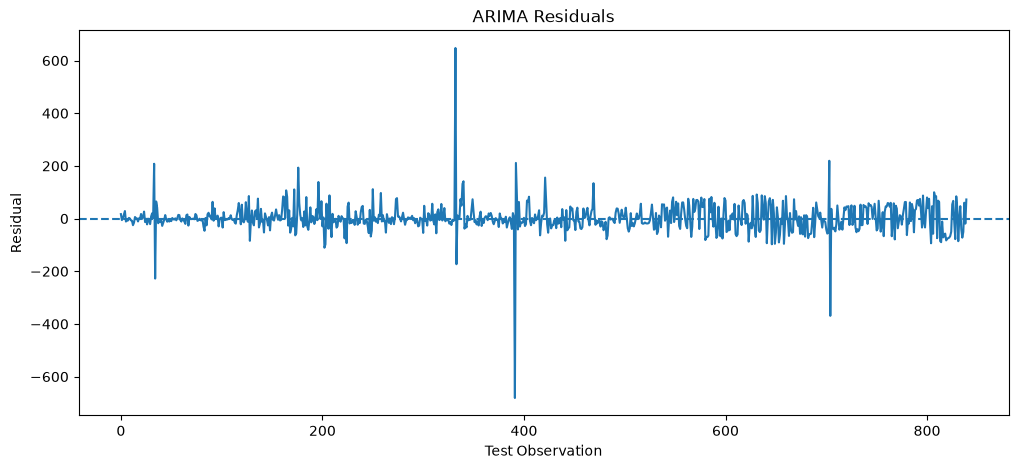

<Figure size 1000x500 with 0 Axes>

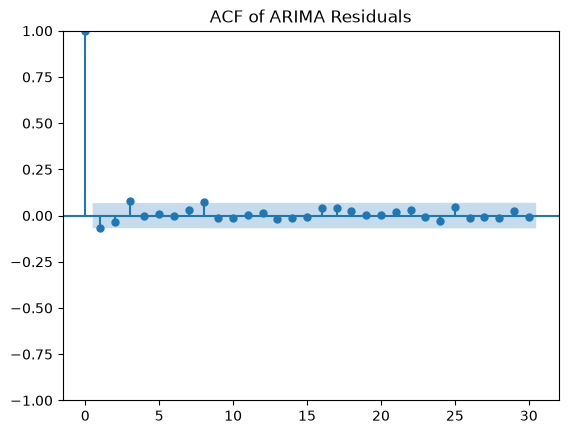


Ljung-Box Test:
      lb_stat  lb_pvalue
10  15.492145   0.115123
20  19.490013   0.490210


In [6]:
# ==========================================
# ARIMA Residual Diagnostics
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ------------------------------------------
# Residuals
# ------------------------------------------

residuals = y_true - y_pred


# ==========================================
# 1. Residual Statistics
# ==========================================

print("=" * 50)
print("ARIMA RESIDUAL DIAGNOSTICS")
print("=" * 50)

print("\nResidual Mean :", np.mean(residuals))
print("Residual Std  :", np.std(residuals))


# ==========================================
# 2. Residual Plot
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("ARIMA Residuals")
plt.xlabel("Test Observation")
plt.ylabel("Residual")

plt.show()


# ==========================================
# 3. Residual ACF
# ==========================================

plt.figure(figsize=(10, 5))

plot_acf(
    residuals,
    lags=30
)

plt.title("ACF of ARIMA Residuals")

plt.show()


# ==========================================
# 4. Ljung-Box Test
# ==========================================

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True
)

print("\nLjung-Box Test:")
print(ljung_box)

In [12]:
# ============================================================
# RIDGE REGRESSION
# FEATURE SET 2
# TARGET = NEXT-DAY PRICE CHANGE
# TIME-SERIES CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 1. Feature Set 2
# ============================================================

features_ridge = [

    # --------------------------------------
    # Price / Daily Movement
    # --------------------------------------
    "HIGH_LOW",
    "OPEN_CLOSE",
    "OPEN_CLOSE_PCT",
    "CLOSE_CHANGE_PCT",

    # --------------------------------------
    # Volume
    # --------------------------------------
    "VOLUME",
    "MA_5",
    "MA_10",
    "VOL_MA_5",

    # --------------------------------------
    # Lag
    # --------------------------------------
    *[f"CLOSE_LAG_{i}" for i in range(1, 21)],

    # --------------------------------------
    # Rolling
    # --------------------------------------
    "MA_20",
    "MA_60",

    "STD_5",
    "STD_10",
    "STD_20",
    "STD_60",

    # --------------------------------------
    # EWMA
    # --------------------------------------
    "EWMA_12",
    "EWMA_26",

    # --------------------------------------
    # Indicators
    # --------------------------------------
    "RSI_14",
    "MACD",
    "MACD_SIGNAL",

    "ROC_5",
    "ROC_10",

    "BB_WIDTH",
    "REALIZED_VOLATILITY",

    # --------------------------------------
    # Volume
    # --------------------------------------
    "VOL_MA_20",
    "VOLUME_RATIO"
]


# ============================================================
# 2. ساخت Target = تغییر قیمت روز بعد
# ============================================================

ridge_df = df.copy().sort_index()


ridge_df["CLOSE"] = ridge_df["adj_close"]


# قیمت روز بعد
ridge_df["NEXT_CLOSE"] = (
    ridge_df["CLOSE"].shift(-1)
)


# تغییر قیمت روز بعد
ridge_df["TARGET_CHANGE"] = (
    ridge_df["NEXT_CLOSE"]
    - ridge_df["CLOSE"]
)


# ============================================================
# 3. ساخت دیتاست نهایی Ridge
# ============================================================

ridge_model_df = ridge_df[
    features_ridge
    + [
        "CLOSE",
        "NEXT_CLOSE",
        "TARGET_CHANGE"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna().copy()


print("=" * 60)
print("RIDGE DATASET")
print("=" * 60)

print(
    "Number of rows:",
    len(ridge_model_df)
)

print(
    "Number of features:",
    len(features_ridge)
)


# ============================================================
# 4. X و Target
# ============================================================

X = ridge_model_df[
    features_ridge
]

y_change = ridge_model_df[
    "TARGET_CHANGE"
]

current_close = ridge_model_df[
    "CLOSE"
]

next_close = ridge_model_df[
    "NEXT_CLOSE"
]


# ============================================================
# 5. تابع SMAPE
# ============================================================

def smape(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    mask = denominator != 0

    return (
        100
        * np.mean(
            2
            * np.abs(
                y_pred[mask]
                - y_true[mask]
            )
            / denominator[mask]
        )
    )


# ============================================================
# 6. Time-Series Cross Validation
# ============================================================

n_splits = 5

n = len(X)

test_size = n // (n_splits + 1)


# ============================================================
# 7. Alphaهای مختلف Ridge
# ============================================================

alpha_values = [
    0.001,
    0.01,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
    20,
    50,
    100
]


alpha_results = []


# ============================================================
# 8. پیدا کردن بهترین Alpha
# ============================================================

for alpha in alpha_values:

    fold_scores = []


    for fold in range(n_splits):

        val_end = (
            n
            - (
                n_splits
                - fold
                - 1
            )
            * test_size
        )

        val_start = (
            val_end
            - test_size
        )

        train_end = val_start


        # -------------------------------
        # Train
        # -------------------------------

        X_train = X.iloc[:train_end]

        y_train = y_change.iloc[:train_end]


        # -------------------------------
        # Validation
        # -------------------------------

        X_val = X.iloc[
            val_start:val_end
        ]

        y_val = y_change.iloc[
            val_start:val_end
        ]

        close_val = current_close.iloc[
            val_start:val_end
        ]


        # -------------------------------
        # Ridge Pipeline
        # -------------------------------

        model = Pipeline([

            (
                "scaler",
                StandardScaler()
            ),

            (
                "ridge",
                Ridge(
                    alpha=alpha
                )
            )
        ])


        # -------------------------------
        # Training
        # -------------------------------

        model.fit(
            X_train,
            y_train
        )


        # -------------------------------
        # Predict Change
        # -------------------------------

        pred_change = model.predict(
            X_val
        )


        # -------------------------------
        # Convert to Price
        # -------------------------------

        pred_price = (
            close_val.values
            + pred_change
        )


        real_price = (
            close_val.values
            + y_val.values
        )


        # -------------------------------
        # SMAPE
        # -------------------------------

        score = smape(
            real_price,
            pred_price
        )


        fold_scores.append(
            score
        )


    alpha_results.append({

        "alpha": alpha,

        "Mean_SM​​APE":
            np.mean(fold_scores),

        "Std_SMAPE":
            np.std(fold_scores)
    })


# ============================================================
# 9. نتایج Alpha
# ============================================================

alpha_results_df = pd.DataFrame(
    alpha_results
)


alpha_results_df = (
    alpha_results_df
    .sort_values("Mean_SM​​APE")
    .reset_index(drop=True)
)


print("\n")
print("=" * 60)
print("RIDGE ALPHA SEARCH")
print("=" * 60)

print(
    alpha_results_df.to_string(
        index=False
    )
)


# ============================================================
# 10. بهترین Alpha
# ============================================================

best_alpha = (
    alpha_results_df.iloc[0]["alpha"]
)


print("\n")
print(
    "BEST ALPHA:",
    best_alpha
)

print(
    "BEST CV SMAPE:",
    alpha_results_df.iloc[0]["Mean_SM​​APE"]
)


# ============================================================
# 11. ارزیابی نهایی روی Test
# ============================================================

# 80% اول برای Train
split = int(
    len(X) * 0.8
)


X_train = X.iloc[:split]

X_test = X.iloc[split:]


y_train = y_change.iloc[:split]

y_test = y_change.iloc[split:]


close_test = current_close.iloc[
    split:
]


# ============================================================
# 12. مدل نهایی Ridge
# ============================================================

final_ridge = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "ridge",
        Ridge(
            alpha=best_alpha
        )
    )
])


# ============================================================
# 13. آموزش
# ============================================================

final_ridge.fit(
    X_train,
    y_train
)


# ============================================================
# 14. Prediction
# ============================================================

pred_change = final_ridge.predict(
    X_test
)


# ============================================================
# 15. تبدیل Change به Price
# ============================================================

pred_price = (
    close_test.values
    + pred_change
)


real_price = (
    close_test.values
    + y_test.values
)


# ============================================================
# 16. Metrics
# ============================================================

mae = mean_absolute_error(
    real_price,
    pred_price
)


rmse = np.sqrt(
    mean_squared_error(
        real_price,
        pred_price
    )
)


smape_score = smape(
    real_price,
    pred_price
)


# ============================================================
# 17. Final Result
# ============================================================

print("\n")
print("=" * 60)
print("FINAL RIDGE - FEATURE SET 2")
print("=" * 60)

print(
    "Number of features:",
    len(features_ridge)
)

print(
    "Best Alpha:",
    best_alpha
)

print(
    f"MAE   : {mae:.4f}"
)

print(
    f"RMSE  : {rmse:.4f}"
)

print(
    f"SMAPE : {smape_score:.4f}%"
)

# ============================================================
# 18. DIRECTIONAL ACCURACY
# ============================================================

# جهت واقعی حرکت قیمت
actual_direction = np.sign(
    real_price - close_test.values
)

# جهت پیش‌بینی‌شده حرکت قیمت
predicted_direction = np.sign(
    pred_price - close_test.values
)

# درصد پیش‌بینی‌های جهت درست
directional_accuracy = np.mean(
    actual_direction == predicted_direction
) * 100


print(
    f"Directional Accuracy : "
    f"{directional_accuracy:.2f}%"
)

RIDGE DATASET
Number of rows: 4137
Number of features: 45


RIDGE ALPHA SEARCH
  alpha  Mean_SM​​APE  Std_SMAPE
100.000      1.535877   0.333354
 50.000      1.541202   0.335015
 20.000      1.550060   0.336382
 10.000      1.557526   0.336798
  5.000      1.565373   0.336954
  2.000      1.575022   0.336446
  1.000      1.581489   0.335940
  0.500      1.587813   0.335221
  0.100      1.606159   0.338070
  0.010      1.621104   0.342856
  0.001      1.623577   0.342714


BEST ALPHA: 100.0
BEST CV SMAPE: 1.5358773517098174


FINAL RIDGE - FEATURE SET 2
Number of features: 45
Best Alpha: 100.0
MAE   : 33.2058
RMSE  : 54.9904
SMAPE : 1.5868%
Directional Accuracy : 58.57%


In [7]:
# ============================================================
# NAIVE BASELINE
# پیش‌بینی قیمت فردا = قیمت امروز
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 60)
print("NAIVE BASELINE")
print("=" * 60)

# ------------------------------------------------------------
# 1. آماده‌سازی داده
# ------------------------------------------------------------

naive_df = df.copy().sort_index()

# قیمت تعدیل‌شده
naive_df["CLOSE"] = naive_df["adj_close"]

# قیمت روز بعد
naive_df["NEXT_CLOSE"] = naive_df["CLOSE"].shift(-1)

# حذف ردیف آخر و مقادیر نامعتبر
naive_df = naive_df[
    ["CLOSE", "NEXT_CLOSE"]
].replace([np.inf, -np.inf], np.nan).dropna()

print("Number of rows:", len(naive_df))

# ------------------------------------------------------------
# 2. همان تقسیم 80/20
# ------------------------------------------------------------

split = int(len(naive_df) * 0.8)

train = naive_df.iloc[:split]
test = naive_df.iloc[split:]

# ------------------------------------------------------------
# 3. Naive Prediction
# پیش‌بینی قیمت فردا = قیمت امروز
# ------------------------------------------------------------

y_test = test["NEXT_CLOSE"].values

y_pred = test["CLOSE"].values

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

smape = np.mean(
    2 * np.abs(y_pred - y_test) /
    (np.abs(y_test) + np.abs(y_pred) + 1e-8)
) * 100

# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NAIVE RESULTS")
print("=" * 60)

print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"SMAPE : {smape:.4f}%")

# ------------------------------------------------------------
# 6. Directional Accuracy
# ------------------------------------------------------------

# قیمت روز قبل از هر روز Test
previous_close = np.concatenate([
    [train["CLOSE"].iloc[-1]],
    test["CLOSE"].values[:-1]
])

# جهت واقعی قیمت فردا نسبت به امروز
actual_direction = np.sign(
    y_test - test["CLOSE"].values
)

# جهت پیش‌بینی‌شده:
# Naive فرض می‌کند جهت فردا مثل جهت امروز است
predicted_direction = np.sign(
    test["CLOSE"].values - previous_close
)

# Directional Accuracy
directional_accuracy = np.mean(
    actual_direction == predicted_direction
) * 100

print(f"Directional Accuracy : {directional_accuracy:.2f}%")

NAIVE BASELINE
Number of rows: 4196

NAIVE RESULTS
MAE   : 33.7666
RMSE  : 55.8011
SMAPE : 1.6137%
Directional Accuracy : 57.26%


DATA
Total samples : 4197
Train samples : 3357
Test samples  : 840


c:\Users\cebit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'




AR / ARMA RESULTS
    Model       MAE      RMSE  MAPE (%)  SMAPE (%)  Directional Accuracy (%)
    Naive   33.7666   55.8011    1.6104     1.6137                   56.5476
    AR(1)  652.2171  785.9565   27.6740    33.4705                   53.5714
ARMA(1,1) 1181.5216 1363.6343   50.2323    72.4686                   55.8333


Best MAE model        : Naive
Best SMAPE model      : Naive
Best Direction model  : Naive


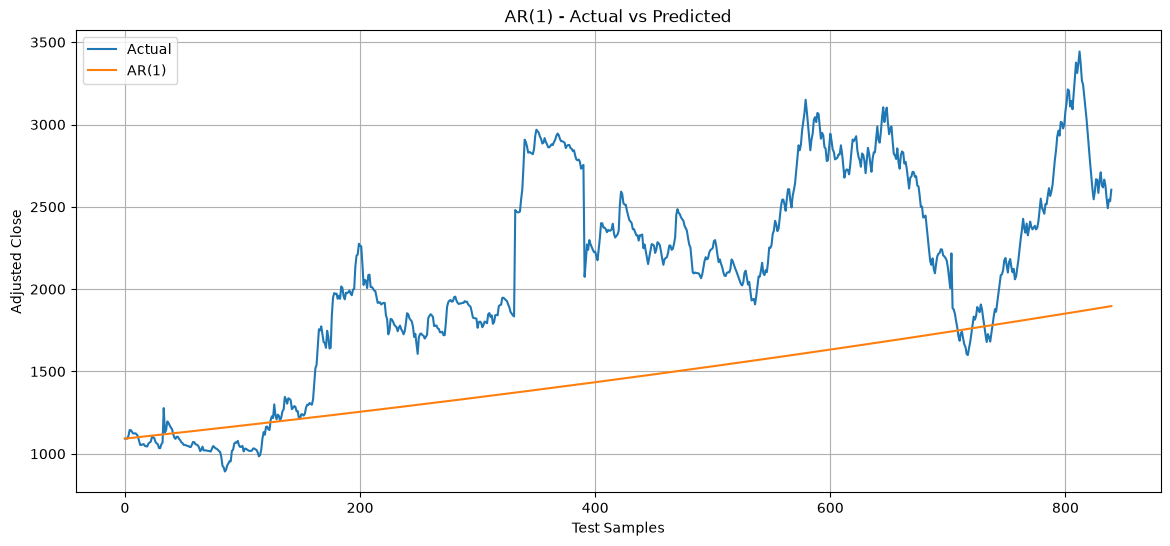

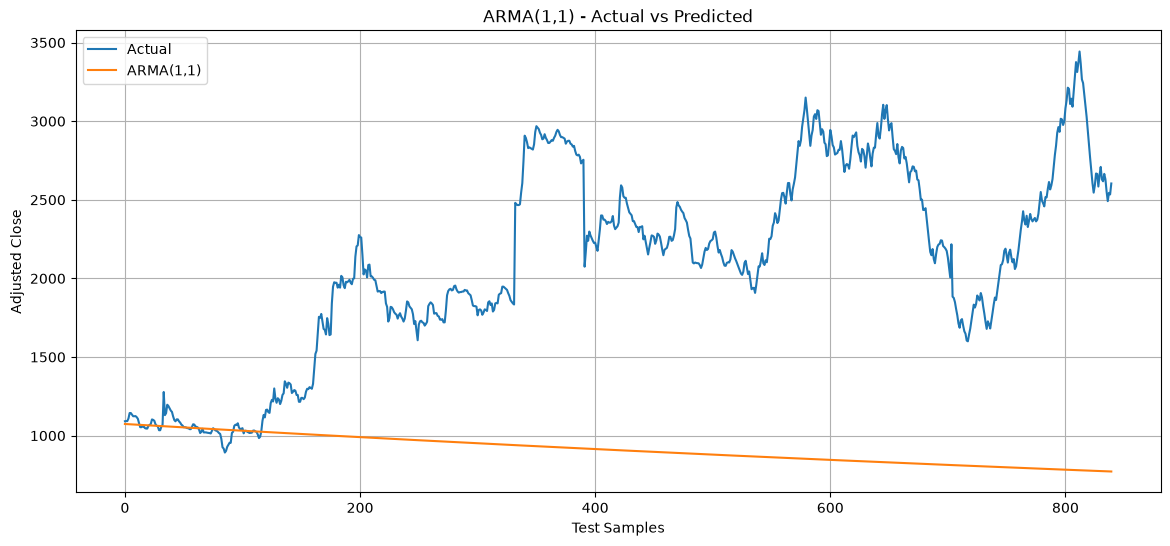

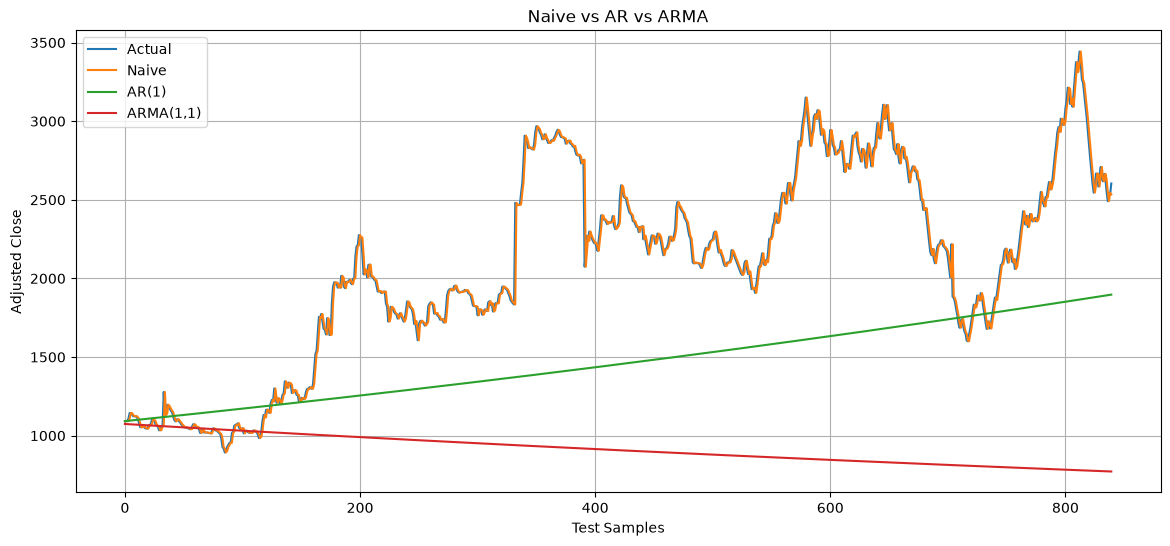

In [7]:
# ============================================================
# AR و ARMA - پیش‌بینی قیمت روز بعد
# + MAE / RMSE / MAPE / SMAPE
# + Directional Accuracy
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 1. آماده‌سازی داده
# ============================================================

data = df.copy()

data = data.sort_index()

# استفاده از قیمت تعدیل‌شده
data["CLOSE"] = data["adj_close"]

data = data[["CLOSE"]].dropna()

prices = data["CLOSE"].values


# ============================================================
# 2. تقسیم Train / Test
# ============================================================

TEST_SIZE = 0.20

split_index = int(
    len(prices) * (1 - TEST_SIZE)
)

train = prices[:split_index]
test = prices[split_index:]


print("=" * 60)
print("DATA")
print("=" * 60)

print(f"Total samples : {len(prices)}")
print(f"Train samples : {len(train)}")
print(f"Test samples  : {len(test)}")


# ============================================================
# 3. تابع محاسبه معیارها
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    previous_prices
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred) /
            (y_true + 1e-10)
        )
    ) * 100

    smape = np.mean(
        2 * np.abs(
            y_pred - y_true
        ) /
        (
            np.abs(y_true) +
            np.abs(y_pred) +
            1e-10
        )
    ) * 100

    # جهت واقعی
    actual_direction = (
        y_true > previous_prices
    ).astype(int)

    # جهت پیش‌بینی‌شده
    predicted_direction = (
        y_pred > previous_prices
    ).astype(int)

    directional_accuracy = (
        np.mean(
            actual_direction ==
            predicted_direction
        )
        * 100
    )

    return (
        mae,
        rmse,
        mape,
        smape,
        directional_accuracy
    )


# ============================================================
# 4. قیمت روز قبل برای Directional Accuracy
# ============================================================

previous_prices = np.empty(
    len(test)
)

# قیمت روز قبل از اولین روز Test
previous_prices[0] = train[-1]

# برای بقیه روزهای Test
previous_prices[1:] = test[:-1]


# ============================================================
# 5. مدل AR
# ============================================================

# AR(1)
AR_LAG = 1

ar_model = AutoReg(
    train,
    lags=AR_LAG,
    trend="c"
)

ar_fit = ar_model.fit()


# ------------------------------------------------------------
# پیش‌بینی کل Test
# ------------------------------------------------------------

ar_pred = ar_fit.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    dynamic=False
)

ar_pred = np.asarray(ar_pred)


# ============================================================
# 6. ارزیابی AR
# ============================================================

(
    ar_mae,
    ar_rmse,
    ar_mape,
    ar_smape,
    ar_directional_accuracy
) = calculate_metrics(
    test,
    ar_pred,
    previous_prices
)


# ============================================================
# 7. مدل ARMA
# ============================================================

# ARMA(1,1)
# در statsmodels با ARIMA(1,0,1)
# پیاده‌سازی می‌شود.

arma_model = ARIMA(
    train,
    order=(1, 0, 1)
)

arma_fit = arma_model.fit()


# ------------------------------------------------------------
# پیش‌بینی Test
# ------------------------------------------------------------

arma_pred = arma_fit.forecast(
    steps=len(test)
)

arma_pred = np.asarray(
    arma_pred
)


# ============================================================
# 8. ارزیابی ARMA
# ============================================================

(
    arma_mae,
    arma_rmse,
    arma_mape,
    arma_smape,
    arma_directional_accuracy
) = calculate_metrics(
    test,
    arma_pred,
    previous_prices
)


# ============================================================
# 9. Naive Baseline
# ============================================================

# پیش‌بینی فردا = قیمت امروز

naive_pred = previous_prices.copy()


(
    naive_mae,
    naive_rmse,
    naive_mape,
    naive_smape,
    naive_directional_accuracy
) = calculate_metrics(
    test,
    naive_pred,
    previous_prices
)


# ============================================================
# 10. نمایش نتایج
# ============================================================

results = pd.DataFrame({

    "Model": [
        "Naive",
        "AR(1)",
        "ARMA(1,1)"
    ],

    "MAE": [
        naive_mae,
        ar_mae,
        arma_mae
    ],

    "RMSE": [
        naive_rmse,
        ar_rmse,
        arma_rmse
    ],

    "MAPE (%)": [
        naive_mape,
        ar_mape,
        arma_mape
    ],

    "SMAPE (%)": [
        naive_smape,
        ar_smape,
        arma_smape
    ],

    "Directional Accuracy (%)": [
        naive_directional_accuracy,
        ar_directional_accuracy,
        arma_directional_accuracy
    ]
})


print("\n")
print("=" * 80)
print("AR / ARMA RESULTS")
print("=" * 80)

print(
    results.round(4).to_string(
        index=False
    )
)


# ============================================================
# 11. بهترین مدل
# ============================================================

best_mae_model = results.loc[
    results["MAE"].idxmin(),
    "Model"
]

best_smape_model = results.loc[
    results["SMAPE (%)"].idxmin(),
    "Model"
]

best_direction_model = results.loc[
    results["Directional Accuracy (%)"].idxmax(),
    "Model"
]


print("\n")
print("Best MAE model        :", best_mae_model)
print("Best SMAPE model      :", best_smape_model)
print("Best Direction model  :", best_direction_model)


# ============================================================
# 12. نمودار AR
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    ar_pred,
    label="AR(1)"
)

plt.title(
    "AR(1) - Actual vs Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Adjusted Close")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 13. نمودار ARMA
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    arma_pred,
    label="ARMA(1,1)"
)

plt.title(
    "ARMA(1,1) - Actual vs Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Adjusted Close")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 14. مقایسه سه مدل
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    naive_pred,
    label="Naive"
)

plt.plot(
    ar_pred,
    label="AR(1)"
)

plt.plot(
    arma_pred,
    label="ARMA(1,1)"
)

plt.title(
    "Naive vs AR vs ARMA"
)

plt.xlabel("Test Samples")
plt.ylabel("Adjusted Close")

plt.legend()
plt.grid(True)

plt.show()